Data Dictionary:
The dataset contains several parameters which were recorded about the passengers.

- PassengerId: Passenger Identifier
- Survived: (0 = No, 1 = Yes) 
- Pclass: - Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd) 
- Name - Name of the Passenger
- Sex:  Gender of the passenger 
- Age: Age in years

SibSp: The "SibSp" represents number of siblings and spouses the passenger had aboard the Titanic. It combines two categories:

- Siblings: Brothers, sisters, stepbrothers, and stepsisters of the passenger.
- Spouses: The passenger’s husband or wife (not including fiancés).
- SibSp = 0: The passenger traveled alone or with no siblings or spouses onboard.
- SibSp > 0: The passenger traveled with at least one sibling or spouse. 

Parch: The "Parch" stands for "Parent or Children." It represents the number of parents or children that each passenger had aboard the Titanic.
* Parents refers to mother or father
* Children refers to sons, daughters, stepsons, or stepdaughters

The values in this column indicate:
- 0 = No parents or children aboard
- 1 = 1 parent or child aboard
- 2 = 2 parents or children aboard 


Ticket: Ticket Number 
Fare: Passenger Fare
Cabin: Cabin - 'U' is for Unkown
Embarked: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [291]:
import pandas as pd
pd.set_option('display.max_columns', 100)
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [292]:
# importing and reading the data
df = pd.read_csv('titanic.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### EDA

In [293]:
print('Olamilekan Elegbede, 041273681')
df.dtypes

Olamilekan Elegbede, 041273681


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [294]:
print('Olamilekan Elegbede, 041273681')
df.describe()

Olamilekan Elegbede, 041273681


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [295]:
print('Olamilekan Elegbede, 041273681')
df.info()

Olamilekan Elegbede, 041273681
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 2.

In [296]:
# number of instances
print('Olamilekan Elegbede, 041273681')
df.shape[0]

Olamilekan Elegbede, 041273681


891

In [297]:
# number of attributes
print('Olamilekan Elegbede, 041273681')
df.shape[1]

Olamilekan Elegbede, 041273681


12

Olamilekan Elegbede, 041273681


<Axes: xlabel='Survived'>

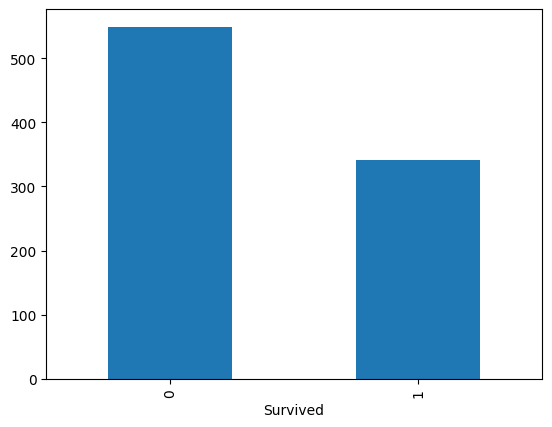

In [298]:
print('Olamilekan Elegbede, 041273681')
df['Survived'].value_counts().plot.bar()

### 3. Data Cleaning

handling missing values

In [299]:
print('Olamilekan Elegbede, 041273681')
df.isna().sum() # OR df.isnull().sum()

Olamilekan Elegbede, 041273681


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [300]:
df[['Age','Cabin','Embarked']].dtypes

Age         float64
Cabin        object
Embarked     object
dtype: object

for numerical columns, use mean/median. in our case, we use median as we want the value to be a whole number not a decimal

In [301]:
df['Age'].median()

28.0

for the categorical variables, we impute using the mode.

In [302]:
df['Cabin'].value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [303]:
print('Cabin mode:', df['Cabin'].mode()[0])

Cabin mode: B96 B98


In [304]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [305]:
print('Embarked mode:', df['Embarked'].mode()[0])

Embarked mode: S


In [306]:
print('Olamilekan Elegbede, 041273681')

# impute all missing values in all the features
# numerical variable
df['Age'].fillna(df['Age'].median(), inplace=True)

# categorical
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

Olamilekan Elegbede, 041273681


In [307]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [308]:
print('Olamilekan Elegbede, 041273681')
# convert the Age to an integer
df['Age'] = df['Age'].astype('int')

Olamilekan Elegbede, 041273681


In [309]:
df[['Age','Cabin','Embarked']].head()

,Age,Cabin,Embarked
0,22,B96 B98,S
1,38,C85,C
2,26,B96 B98,S
3,35,C123,S
4,35,B96 B98,S


### Data Preparation

In [310]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,B96 B98,S


In [311]:
print('Olamilekan Elegbede, 041273681')
# columns to drop
# passenderid, cabin, name, ticket
drop_col = ['PassengerId','Name','Ticket','Cabin']

if all(col in df.columns for col in drop_col):
    df.drop(drop_col, axis=1, inplace=True)

df.head()

Olamilekan Elegbede, 041273681


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S


Convert categorical columns - get_dummies

In [312]:
df = pd.get_dummies(df, columns=['Sex','Embarked'], dtype=int)
df.head(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22,1,0,7.2500,0,1,0,0,1
1,1,1,38,1,0,71.2833,1,0,1,0,0


In [313]:
x = df.drop('Survived', axis = 1) # features
y = df['Survived'] # target variable
y.head(2)

0    0
1    1
Name: Survived, dtype: int64

split to train and test

In [314]:
# splitting the data in training and testing set
from sklearn.model_selection import train_test_split

test_s = 0.3

xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size= test_s, stratify=df['Survived'])

In [315]:
ytrain.value_counts()

Survived
0    384
1    239
Name: count, dtype: int64

Normalize the variables

In [316]:
# scale the data using min-max scalar
from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()

# Fit-transform on train data
xtrain_scaled = scale.fit_transform(xtrain)
xtest_scaled = scale.transform(xtest)

### Logistic Regression

In [317]:
print('Olamilekan Elegbede, 041273681')

from sklearn.linear_model import LogisticRegression

lrmodel = LogisticRegression().fit(xtrain_scaled, ytrain)

ypred = lrmodel.predict(xtest_scaled)

Olamilekan Elegbede, 041273681


Logistic Regression classification accuracy: 0.77


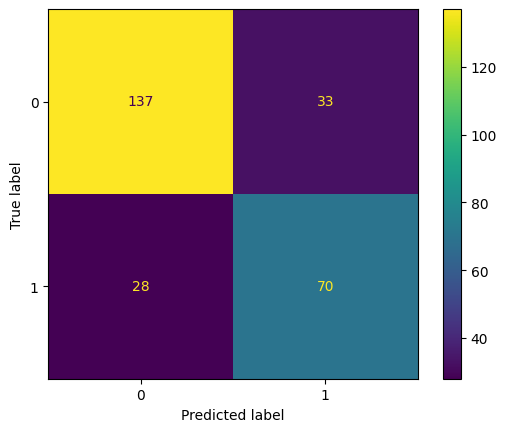

In [318]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics

print('Logistic Regression classification accuracy:', round(accuracy_score(ypred, ytest),2))

# plot confusion metrix
conf_mat = confusion_matrix(ypred, ytest)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix= conf_mat)

disp.plot()
plt.show()


### Decision Tree

In [319]:
print('Olamilekan Elegbede, 041273681')

# Import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Model
dtmodel = DecisionTreeClassifier().fit(xtrain_scaled, ytrain)

Olamilekan Elegbede, 041273681


Decision Tree classification accuracy: 0.75


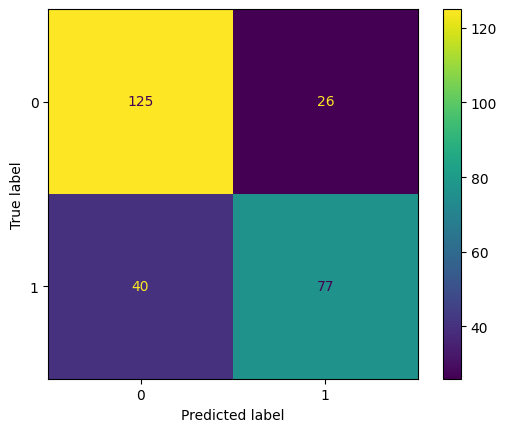

In [320]:
ypred = dtmodel.predict(xtest_scaled)

print('Decision Tree classification accuracy:', round(accuracy_score(ypred, ytest),2))

# plot confusion metrix
conf_mat = confusion_matrix(ypred, ytest)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix= conf_mat)

disp.plot()
plt.show()

### Random Forest Classification

In [321]:
print('Olamilekan Elegbede, 041273681')

# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier()
rfmodel.fit(xtrain_scaled,ytrain)

Olamilekan Elegbede, 041273681


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Random forest classification accuracy: 0.77


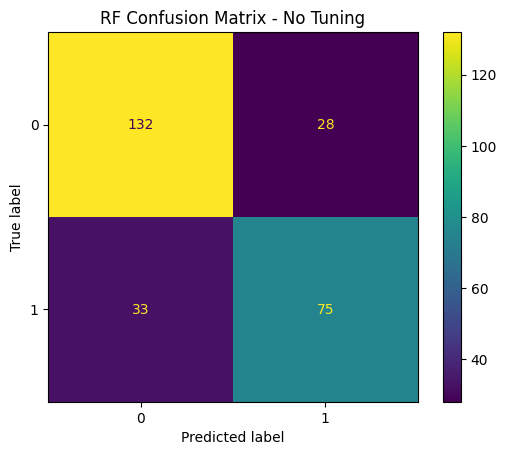

In [322]:
ypred = rfmodel.predict(xtest_scaled)

print('Random forest classification accuracy:', round(accuracy_score(ypred, ytest),2))

# plot confusion metrix
conf_mat = confusion_matrix(ypred, ytest)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix= conf_mat)

disp.plot()
plt.title('RF Confusion Matrix - No Tuning')
plt.show()

tuning hyperparameters

Olamilekan Elegbede, 041273681
Random forest classification accuracy: 0.81


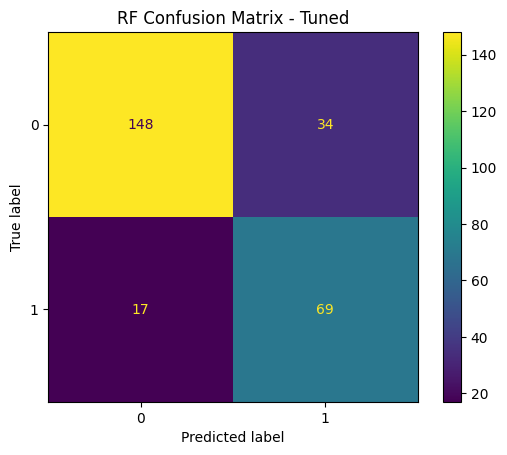

In [323]:
print('Olamilekan Elegbede, 041273681')

rfmodel = RandomForestClassifier(n_estimators=200,
                                 max_depth=4,
                                 max_features=5)

rfmodel.fit(xtrain, ytrain)

# predict on xtest
ypred = rfmodel.predict(xtest)

print('Random forest classification accuracy:', round(accuracy_score(ypred, ytest),2))

# plot confusion metrix
conf_mat = confusion_matrix(ypred, ytest)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix= conf_mat)

disp.plot()
plt.title('RF Confusion Matrix - Tuned')
plt.show()

using gridsearchcv

Olamilekan Elegbede, 041273681
Random forest classification accuracy: 0.81


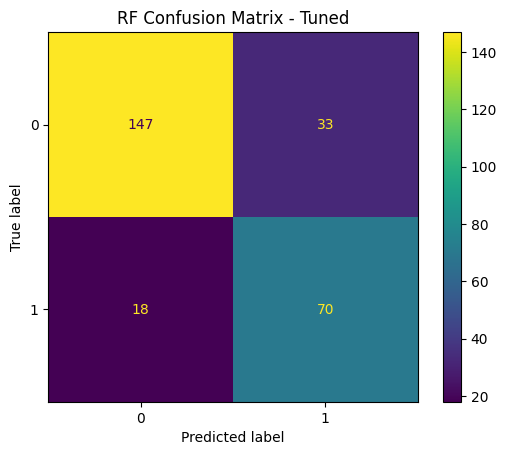

In [324]:
print('Olamilekan Elegbede, 041273681')

from sklearn.model_selection import GridSearchCV

rfmodel = RandomForestClassifier()

# defir parameters for gridsearch
cv_params = {
    'n_estimators' : [200],
    'max_depth':[4],
    'max_features': [5]
}

# confstruct gridsearcg
rf_cv = GridSearchCV(rfmodel, cv_params)
rf_cv.fit(xtrain, ytrain)

# predict on xtest
ypred = rf_cv.predict(xtest)

print('Random forest classification accuracy:', round(accuracy_score(ypred, ytest),2))

# plot confusion metrix
conf_mat = confusion_matrix(ypred, ytest)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix= conf_mat)

disp.plot()
plt.title('RF Confusion Matrix - Tuned')
plt.show()

### Cross Validation

In [325]:
# import rquired libraries
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# if you have a imbalanced dataset, you can use stratifiedKFold
from sklearn.model_selection import StratifiedKFold

logistic regression

In [326]:
print('Olamilekan Elegbede, 041273681')

# Set up a KFold cross-validation
kfold = KFold(n_splits=5)

# Use cross-validation to evaluate the model
lr_scores = cross_val_score(lrmodel, xtrain_scaled, ytrain, cv=kfold)

# Print the accuracy scores for each fold
print("Accuracy scores:", lr_scores)

# Print the mean accuracy and standard deviation of the model
print("Mean accuracy:", lr_scores.mean())
print("Standard deviation:", lr_scores.std())

Olamilekan Elegbede, 041273681
Accuracy scores: [0.816      0.744      0.816      0.85483871 0.76612903]
Mean accuracy: 0.7993935483870968
Standard deviation: 0.03949857622007547


decision tree

In [327]:
print('Olamilekan Elegbede, 041273681')

# Set up a KFold cross-validation
kfold = KFold(n_splits=5)

# Use cross-validation to evaluate the model
dt_scores = cross_val_score(dtmodel, xtrain_scaled, ytrain, cv=kfold)

# Print the accuracy scores for each fold
print("Accuracy scores:", dt_scores)

# Print the mean accuracy and standard deviation of the model
print("Mean accuracy:", dt_scores.mean())
print("Standard deviation:", dt_scores.std())

Olamilekan Elegbede, 041273681


Accuracy scores: [0.776      0.688      0.76       0.75       0.80645161]
Mean accuracy: 0.7560903225806452
Standard deviation: 0.03904183513538797


random forest

In [328]:
print('Olamilekan Elegbede, 041273681')

# Set up a KFold cross-validation
kfold = KFold(n_splits=5)

# Use cross-validation to evaluate the model
rf_scores = cross_val_score(rfmodel, xtrain_scaled, ytrain, cv=kfold)

# Print the accuracy scores for each fold
print("Accuracy scores:", rf_scores)

# Print the mean accuracy and standard deviation of the model
print("Mean accuracy:", rf_scores.mean())
print("Standard deviation:", rf_scores.std())

Olamilekan Elegbede, 041273681
Accuracy scores: [0.864      0.76       0.848      0.79032258 0.78225806]
Mean accuracy: 0.8089161290322581
Standard deviation: 0.04002734549151085


## Model Evaluation

Olamilekan Elegbede, 041273681
=== Split 80:20 ===
Logistic Regression accuracy: 0.7933


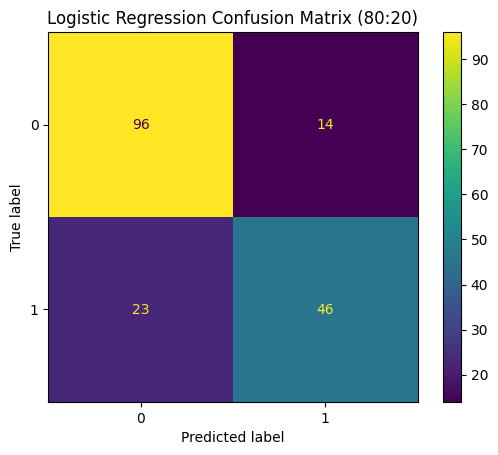

Decision Tree accuracy: 0.8268


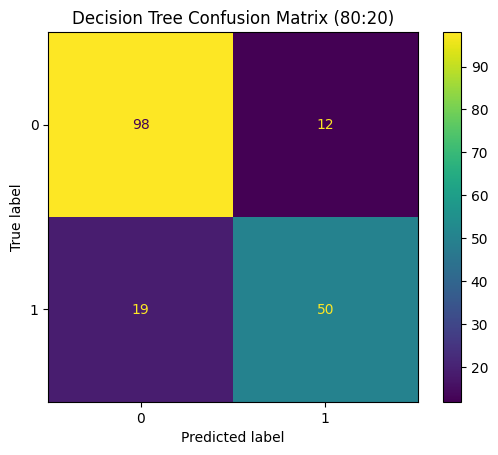

Random Forest accuracy: 0.8045


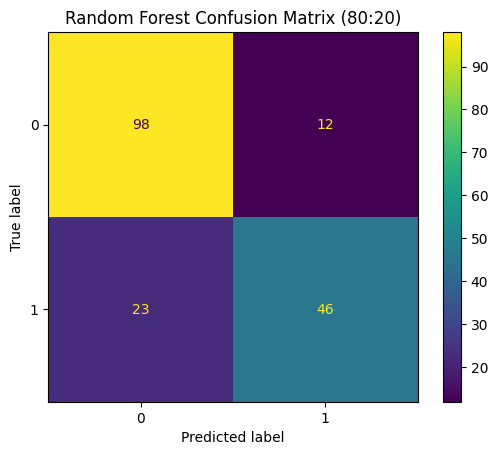

=== Split 70:30 ===
Logistic Regression accuracy: 0.8060


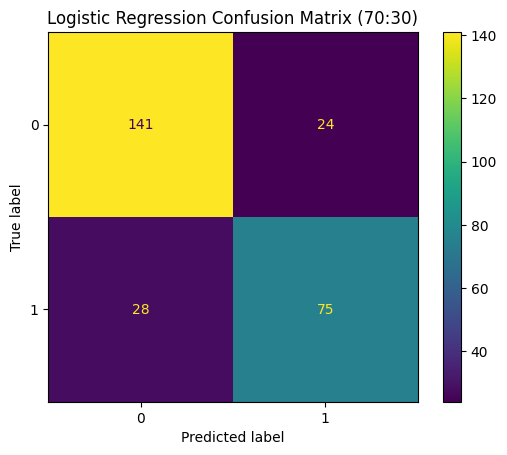

Decision Tree accuracy: 0.7612


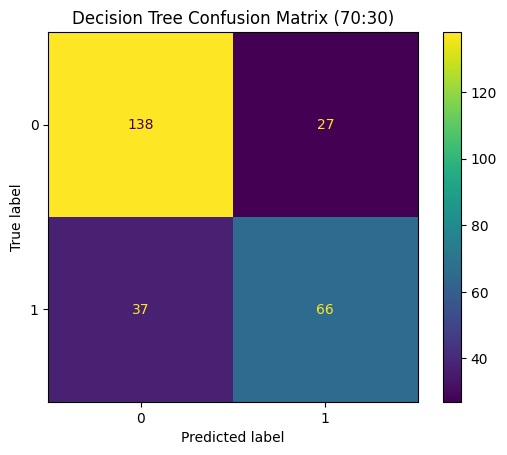

Random Forest accuracy: 0.8022


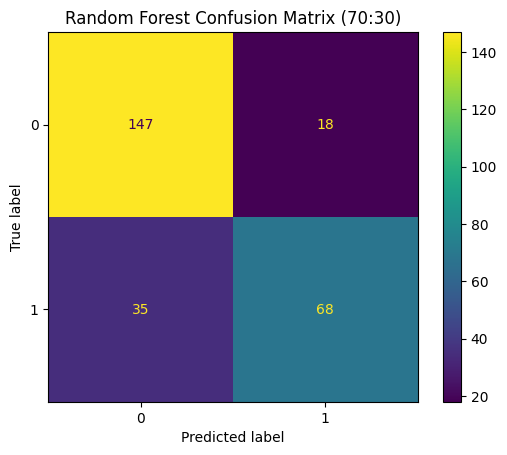

=== Split 85:15 ===
Logistic Regression accuracy: 0.7537


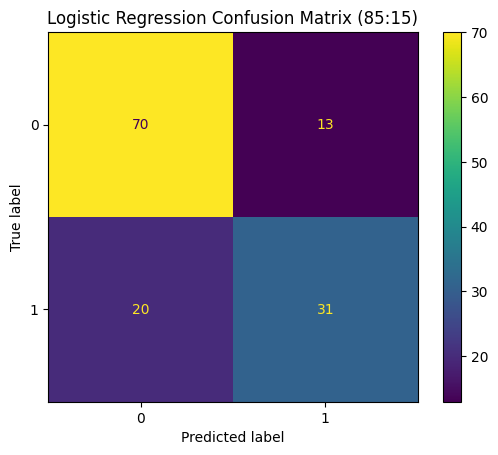

Decision Tree accuracy: 0.7388


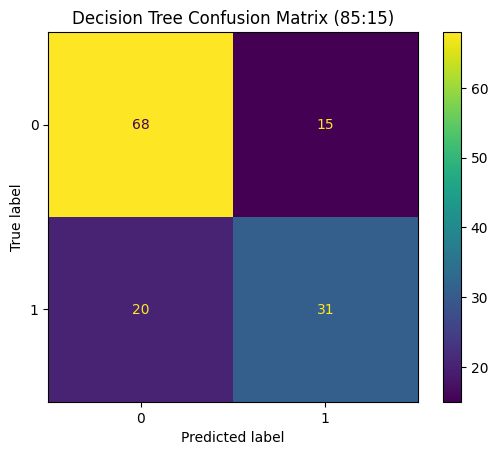

Random Forest accuracy: 0.7687


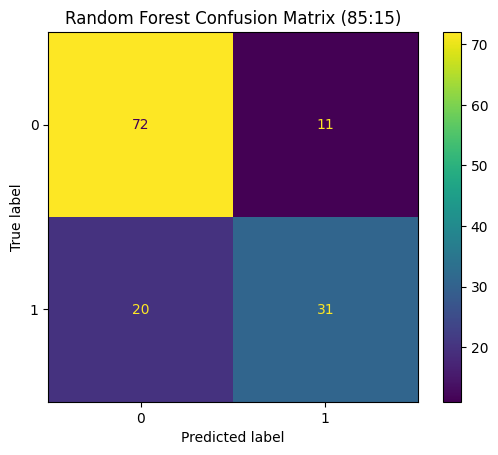

,split,model,accuracy
4,70:30,Decision Tree,0.761194
3,70:30,Logistic Regression,0.805970
5,70:30,Random Forest,0.802239
1,80:20,Decision Tree,0.826816
0,80:20,Logistic Regression,0.793296
2,80:20,Random Forest,0.804469
7,85:15,Decision Tree,0.738806
6,85:15,Logistic Regression,0.753731
8,85:15,Random Forest,0.768657



Best overall result:
{'split': '80:20', 'model': 'Decision Tree', 'accuracy': 0.8268156424581006}


,split,model,accuracy
3,70:30,Logistic Regression,0.805970
1,80:20,Decision Tree,0.826816
8,85:15,Random Forest,0.768657


In [329]:
print('Olamilekan Elegbede, 041273681')

# Evaluate multiple train/test splits and compare accuracy + confusion matrix for each model
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

split_settings = [
    (0.2, '80:20'),
    (0.3, '70:30'),
    (0.15, '85:15')
]

models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42))
]

results = []

for test_size, label in split_settings:
    xtrain, xtest, ytrain, ytest = train_test_split(
        x, y, test_size=test_size, stratify=y, random_state=42
    )

    scaler = MinMaxScaler()
    xtrain_scaled = scaler.fit_transform(xtrain)
    xtest_scaled = scaler.transform(xtest)

    print(f'=== Split {label} ===')
    for name, model in models:
        model.fit(xtrain_scaled, ytrain)
        ypred = model.predict(xtest_scaled)
        acc = accuracy_score(ytest, ypred)
        results.append({'split': label, 'model': name, 'accuracy': acc})

        print(f'{name} accuracy: {acc:.4f}')
        conf_mat = confusion_matrix(ytest, ypred)
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=model.classes_)
        disp.plot()
        plt.title(f'{name} Confusion Matrix ({label})')
        plt.show()

results_df = pd.DataFrame(results)
display(results_df.sort_values(['split', 'model']))

best_overall = results_df.loc[results_df['accuracy'].idxmax()]
print('\nBest overall result:')
print(best_overall.to_dict())

best_per_split = results_df.loc[results_df.groupby('split')['accuracy'].idxmax()]
display(best_per_split.sort_values('split'))